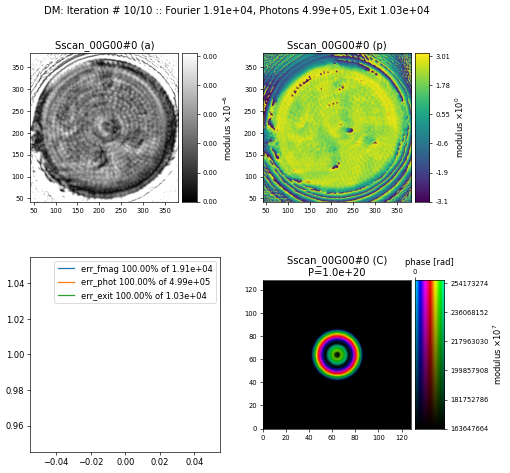


==== This reconstruction relied on the following work ==========================
The Ptypy framework:
    Enders B. and Thibault P., "A computational framework for ptychographic reconstructions" Proc. Royal Soc. A 472 (2016) 20160640, doi: 10.1098/rspa.2016.0640.
The difference map reconstruction algorithm:
    Thibault et al., "Probe retrieval in ptychographic coherent diffractive imaging" Ultramicroscopy 109 (2009) 338, doi: 10.1016/j.ultramic.2008.12.011.


In [36]:

"""
This script is a test for ptychographic reconstruction in the absence
of actual data. It uses the test Scan class
`ptypy.core.data.MoonFlowerScan` to provide "data".
"""
from ptypy.core import Ptycho
from ptypy import utils as u

import tempfile
import os
import ptypy
from ptypy import io
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
#ptypy.load_ptyscan_module("MoonFlowerScan")

import h5py, os
home_path = "/data/staff/nanomax/reblex/temporary/"
data_path = home_path + "ptypy/data/data_scan_dls_i08_nanogold_small.ptyd"
path_dumps = home_path + 'ptypy/dumps/dump_scan_dls_i08_nanogold_small_%(engine)s_%(iterations)04d.ptyr'  # intermediate
tutorial_data_home = "/data/staff/nanomax/reblex/temporary/data/"
dataset = "small_data/dls_i08_nanogold_small.h5"
path_to_data = os.path.join(tutorial_data_home, dataset)
with h5py.File(path_to_data) as f:
    print("The file {} has the following entries: \n".format(path_to_data))
    print('\n'.join('\t* {0:<13} \tshape = {1:}'.format(k,f[k].shape) for k in list(f)))

    
ptypy.load_ptyscan_module("hdf5_loader")

# Create parameter tree
p = u.Param()

# Set verbose level to interactive
p.verbose_level = "interactive"

# Set io settings (no files saved)
p.io = u.Param()
p.io.rfile = None
p.io.autosave = u.Param(active=True)
p.io.autosave.rfile = path_dumps  # where to save the intermediate reconstructions and how to name them
p.io.interaction = u.Param(active=False)

# Live-plotting during the reconstruction
p.io.autoplot = u.Param()
p.io.autoplot.active=False
p.io.autoplot.threaded = False
p.io.autoplot.layout = "jupyter"
p.io.autoplot.interval = 10

# Define the scan model
p.scans = u.Param()
p.scans.scan_00 = u.Param()
p.scans.scan_00.name = 'Full'

# Initial illumination (based on simulated optics)
p.scans.scan_00.illumination = u.Param()
p.scans.scan_00.illumination.model = None
p.scans.scan_00.illumination.photons = 1e20#None
p.scans.scan_00.illumination.aperture = u.Param()
p.scans.scan_00.illumination.aperture.form = "circ"
p.scans.scan_00.illumination.aperture.size = 333e-6
p.scans.scan_00.illumination.propagation = u.Param()
p.scans.scan_00.illumination.propagation.focussed = 13.725e-3
p.scans.scan_00.illumination.propagation.parallel = 45e-6

p.scans.scan_00.data = u.Param()
p.scans.scan_00.data.name = 'Hdf5Loader'
#p.scans.scan_00.data.path = "/data/staff/nanomax/reblex/temporary/ptypy"
p.scans.scan_00.data.save = 'append'
p.scans.scan_00.data.dfile = data_path



p.scans.scan_00.data.intensities = u.Param()
p.scans.scan_00.data.intensities.file = path_to_data
p.scans.scan_00.data.intensities.key = "data"

p.scans.scan_00.data.positions = u.Param()
p.scans.scan_00.data.positions.file = path_to_data
p.scans.scan_00.data.positions.slow_key = "posy_mm"
p.scans.scan_00.data.positions.slow_multiplier = 1e-3
p.scans.scan_00.data.positions.fast_key = "posx_mm"
p.scans.scan_00.data.positions.fast_multiplier = 1e-3

p.scans.scan_00.data.recorded_energy = u.Param()
p.scans.scan_00.data.recorded_energy.file = path_to_data
p.scans.scan_00.data.recorded_energy.key = "energy_ev"
p.scans.scan_00.data.recorded_energy.multiplier = 1e-3

p.scans.scan_00.data.recorded_distance = u.Param()
p.scans.scan_00.data.recorded_distance.file = path_to_data
p.scans.scan_00.data.recorded_distance.key = "det_distance_mm"
p.scans.scan_00.data.recorded_distance.multiplier = 1e-3

p.scans.scan_00.data.recorded_psize = u.Param()
p.scans.scan_00.data.recorded_psize.file = path_to_data
p.scans.scan_00.data.recorded_psize.key = "det_pixelsize_um"
p.scans.scan_00.data.recorded_psize.multiplier = 1e-6


p.engines = u.Param()
p.engines.engine = u.Param()
p.engines.engine.name = "DM"
p.engines.engine.numiter = 10
p.engines.engine.numiter_contiguous = 10
p.engines.engine.alpha = 0.9
p.engines.engine.probe_support = None
p.engines.engine.probe_update_start = 0

P = ptypy.core.Ptycho(p,level=5)

In [37]:
#Load initial probe
from ptypy import io
#data_init_fname = p.io.home + "/dumps/ipykernel_launcher/ipykernel_launcher_None_0000.ptyr"
data_init_fname = "/data/staff/nanomax/reblex/temporary/ptypy/dumps/dump_scan_dls_i08_nanogold_small_None_0000.ptyr"
obj_init = io.h5read(data_init_fname, 'content/obj/Sscan_00G00/data')['content/obj/Sscan_00G00/data']
pr_init = io.h5read(data_init_fname, 'content/probe/Sscan_00G00/data')['content/probe/Sscan_00G00/data'][0]

In [38]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

#plt.imshow(np.abs(pr_init))
print(np.sum(np.abs(pr_init)))
"""
illumination.photons = None : 1409879.2
illumination.photons = 1e10 : 6891368.5
illumination.photons = 1e20 : 689136860000.0
""";

689136860000.0


In [39]:

diffractions = P.diff.S['S0000'].data
sumphotons = 0
for k in range(0,diffractions.shape[0]):
    sumphotons += np.sum(diffractions[k])
print('Average photons per diffraction patterns: ', sumphotons/diffractions.shape[0])
"""
illumination.photons = None : 51650047.04950494
illumination.photons = 1e10 : 351650047.04950494
illumination.photons = 1e20 : 351650047.04950494
""";

Average photons per diffraction patterns:  351650047.04950494


In [40]:
probe = P.probe.S['Sscan_00G00'].data
print(np.sum(np.abs(probe)))
"""
illumination.photons = None : 1488842.5
illumination.photons = 1e10 : 7310778.5
illumination.photons = 1e20 : 685498430000.0
""";

685498430000.0


In [52]:
np.sqrt(1e20)/(128*128)

610351.5625